# KYA face identification demo - MLP neural network training, Leo transpilation, Aleo deployment

## Overview of steps
* 📦 Ensure Leo and Python library installation
* 🧑‍🔬 Load default Einstein images
* 📷 Capture your own face (optional)
* 📂 Load the dataset and extract the features
* ✂️ Split into a training and test dataset
* 🏋️ Train the model
* 📊 Evaluate the model
* 🔄 PCA feature transformation
* 🔁 Re-train and evaluate the model
* ⚙️ Transpile to Leo
* ▶️ Test execution of the Leo program
* 🚀 Deploy the Leo program
* 💡 Extension ideas
* 🗣️ Discussion

## 📦 Ensure Leo and Python library installation
For this Jupyter notebook to run successfully, you need to ensure Leo and selected Python libraries are installed. If you haven't done already ... (todo)

In [1]:
from zkml import LeoTranspiler
import os
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import face_recognition
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from helper import plot_mlp_architecture, summarize_mlp
import random

/Users/kp/dev/python-sdk2/zkml-research/KYA_face/.venv/lib/python3.12/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 🧑‍🔬 Load default Einstein images
In this notebook, we use 5 JPG images of Albert Einstein as the positive class.
You can replace these with 5 JPG images of yourself - place the files `1.jpg`, `2.jpg`, `3.jpg`, `4.jpg`, `5.jpg` in the folder.

The following code ensures the files inside the positive class folder are correctly set up.

In [2]:
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

positive_dir_path = os.path.join(cwd, 'face_images', 'positive_einstein')
if not os.path.isdir(positive_dir_path):
    raise FileNotFoundError(f"Directory not found: {positive_dir_path}")

Current working directory: /Users/kp/dev/python-sdk2/zkml-research/KYA_face


In [3]:
files = sorted(f for f in os.listdir(positive_dir_path)
               if os.path.isfile(os.path.join(positive_dir_path, f)))
expected = ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']
if files != expected:
    raise ValueError(f"Expected {expected}, but found {files}")
print(f"Found expected files: {files}")

Found expected files: ['1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg']


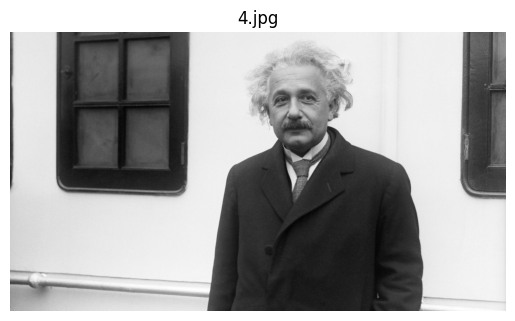

In [4]:
image_path = os.path.join(positive_dir_path, '4.jpg')
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.title('4.jpg')
plt.show()

## 📷 Capture your own face (optional)

In [5]:
# Toggle here ⬇️
CAPTURE_MY_FACE = False # ← change to True to enable capture

In [6]:
N_IMAGES = 5

if CAPTURE_MY_FACE:
    print(f"📸 You'll be prompted to capture {N_IMAGES} images. You may need to run the cell below twice, and approve the webcam use after the first run.")
else:
    print("Skipping webcam capture (CAPTURE_MY_FACE = False)")

Skipping webcam capture (CAPTURE_MY_FACE = False)


In [7]:
if CAPTURE_MY_FACE:
    import cv2, time, platform, os
    from pathlib import Path
    from IPython.display import clear_output, display, Markdown
    from PIL import Image
    import face_recognition

    # ---------- choose camera index ----------
    def builtin_mac_cam_index():
        """
        Return the index of the built-in FaceTime camera on macOS.
        Falls back to 0 if PyObjC or AVFoundation is unavailable.
        """
        if platform.system() != "Darwin":
            return 0

        try:
            # Lightweight ObjC bridge (adds ~1.9 MB, macOS only)
            from AVFoundation import (
                AVCaptureDevice,
                AVMediaTypeVideo,
                AVCaptureDeviceTypeBuiltInWideAngleCamera,
                AVCaptureDeviceTypeBuiltInTrueDepthCamera,
            )

            devices = AVCaptureDevice.devicesWithMediaType_(AVMediaTypeVideo)

            # 1st pass: transport type == Built-In
            for idx, dev in enumerate(devices):
                if dev.transportType().value == "BuiltIn":  # “USB”, “Virtual”, etc. otherwise
                    return idx

            # 2nd pass: deviceType == Built-in wide-angle / TrueDepth
            for idx, dev in enumerate(devices):
                if dev.deviceType() in (
                    AVCaptureDeviceTypeBuiltInWideAngleCamera,
                    AVCaptureDeviceTypeBuiltInTrueDepthCamera,
                ):
                    return idx

            # 3rd pass: name contains “FaceTime”
            for idx, dev in enumerate(devices):
                if "FaceTime" in str(dev.localizedName()):
                    return idx

        except Exception as e:  # PyObjC not installed, or unexpected API change
            pass

        return 0  # graceful fallback

    backend = cv2.CAP_AVFOUNDATION if platform.system() == "Darwin" else cv2.CAP_ANY
    cam_index = builtin_mac_cam_index()
    cam = cv2.VideoCapture(cam_index, backend)
    assert cam.isOpened(), f"❌ Cannot open camera index {cam_index}"

    print(f"📷 Using camera index {cam_index} "
          f"({'FaceTime built-in' if platform.system()=='Darwin' else 'default'})")

    # ---------- capture loop ----------
    positive_dir = Path.cwd() / "face_images" / "positive_user"
    positive_dir.mkdir(parents=True, exist_ok=True)

    captured = attempts = 0
    MAX_ATTEMPTS, INTERVAL_SEC = 20, 1

    while captured < N_IMAGES and attempts < MAX_ATTEMPTS:
        time.sleep(INTERVAL_SEC)
        ok, frame = cam.read()
        if not ok:
            attempts += 1
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        encs = face_recognition.face_encodings(rgb)

        if len(encs) == 1:
            out_path = positive_dir / f"{captured+1}.jpg"
            cv2.imwrite(str(out_path), frame)
            clear_output(wait=True)
            display(Image.fromarray(rgb))
            print(f"✔️  Saved {out_path.name} ({captured+1}/{N_IMAGES})")
            captured += 1
        else:
            print(f"⏭️  Attempt {attempts+1}: expected 1 face, found {len(encs)} — retrying")

        attempts += 1

    cam.release()
    cv2.destroyAllWindows()

    if captured == N_IMAGES:
        display(Markdown("### ✅ All images captured, validated & saved!"))
        positive_dir_path = os.path.join(cwd, 'face_images', 'positive_user')
    else:
        raise RuntimeError(
            f"Only captured {captured} of {N_IMAGES} images; please rerun."
        )
else:
    print("Skipping webcam capture (CAPTURE_MY_FACE = False)")

Skipping webcam capture (CAPTURE_MY_FACE = False)


## 📂 Load the dataset and extract the features

In [8]:
def iter_face_embeddings(directory: Path, label: int):
    """
    Yields dicts with keys:
      - 'filename': str
      - 'label':    int (1=positive, 0=negative)
      - 'embedding': np.ndarray shape (128,)
    """
    for img_path in sorted(directory.iterdir()):
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
            continue
        image = face_recognition.load_image_file(str(img_path))
        encs = face_recognition.face_encodings(image)
        if not encs:
            print(f"[warn] no face in {img_path.name}, skipping")
            continue
        yield {
            'filename': img_path.name,
            'label': label,
            'embedding': encs[0]
        }

In [9]:
# also define negative_dir_path
negative_dir_path = os.path.join(cwd, 'face_images', 'negative')

# collect records
records = list(iter_face_embeddings(Path(positive_dir_path), label=1)) \
        + list(iter_face_embeddings(Path(negative_dir_path), label=0))

# DataFrame with metadata + raw embeddings
df = pd.DataFrame(records)

# stack embeddings into an (n_samples × 128) array
X = np.stack(df['embedding'].values)
y = df['label'].values

In [10]:
df.head()

,filename,label,embedding
0,1.jpg,1,"[-0.13916254043579102, 0.06765440106391907, 0...."
1,2.jpg,1,"[-0.10024195909500122, 0.060482949018478394, 0..."
2,3.jpg,1,"[-0.11690331250429153, -0.0040309554897248745,..."
3,4.jpg,1,"[-0.1615755558013916, 0.07210954278707504, 0.0..."
4,5.jpg,1,"[-0.057057902216911316, 0.01846969872713089, 0..."


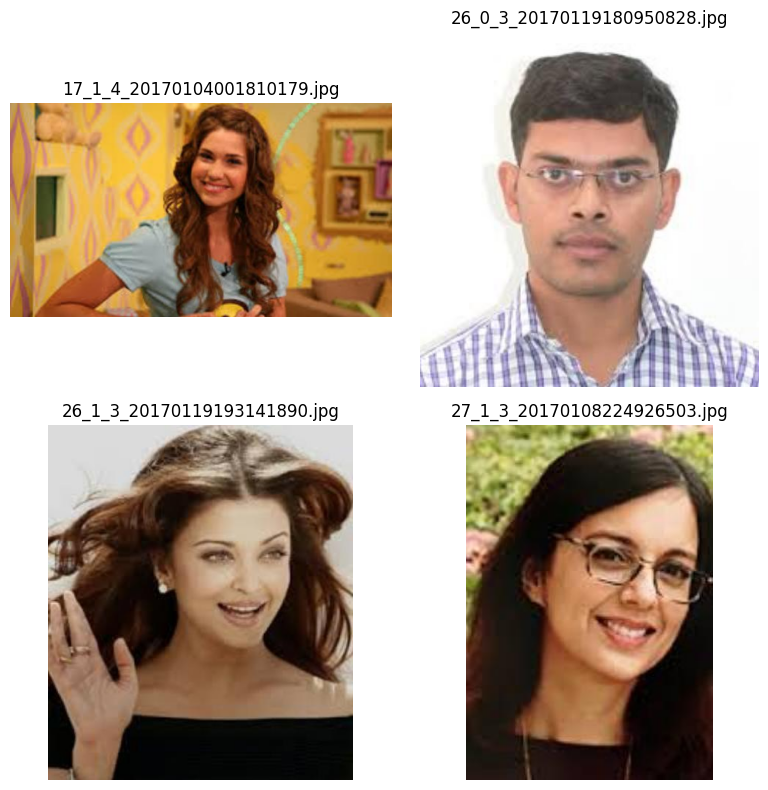

In [11]:
indices = [9, 24, 29, 32]

# Fetch those filenames
filenames = df.loc[indices, 'filename'].tolist()

# create a 2×2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, fname in zip(axes.flatten(), filenames):
    image_path = os.path.join(negative_dir_path, fname)
    img = Image.open(image_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(fname)

plt.tight_layout()
plt.show()

## ✂️ Split into a training and test dataset

In [12]:
# 1) Positive class: first two → train, last one → test
df_pos = df[df['label'] == 1].reset_index(drop=True)
train_pos = df_pos.iloc[[0, 1, 2]]   # 1.jpg, 2.jpg
test_pos  = df_pos.iloc[[3, 4]]      # 3.jpg

# 2) Negative class: random 2/3 train, 1/3 test (seed=42)
df_neg = df[df['label'] == 0].reset_index(drop=True)
train_neg, test_neg = train_test_split(
    df_neg,
    test_size=1/3,
    random_state=42,
    shuffle=True
)

# 3) Combine back together
train_df = pd.concat([train_pos, train_neg]).reset_index(drop=True)
test_df  = pd.concat([test_pos,  test_neg]).reset_index(drop=True)

# 4) Extract X / y arrays
X_train = np.stack(train_df['embedding'].values)
y_train = np.eye(2)[train_df['label'].values]

X_test  = np.stack(test_df['embedding'].values)
y_test  = np.eye(2)[test_df['label'].values]

# 5) Quick sanity check
print(f"Training samples: {len(train_df)}  (pos={len(train_pos)}, neg={len(train_neg)})")
print(f" Testing samples: {len(test_df)}  (pos={len(test_pos)}, neg={len(test_neg)})")

Training samples: 68  (pos=3, neg=65)
 Testing samples: 35  (pos=2, neg=33)


In [13]:
# 1) Initialize scaler
scaler = StandardScaler()

# 2) Fit on training data only, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 3) (Optional) check means/vars
print("Train mean (first 3 features):", X_train_scaled.mean(axis=0)[:3])
print("Train std  (first 3 features):", X_train_scaled.std(axis=0)[:3])

Train mean (first 3 features): [-5.36106086e-17  2.44902138e-18  1.95309455e-16]
Train std  (first 3 features): [1. 1. 1.]


## Train the model

In [14]:
clf_large = MLPClassifier(hidden_layer_sizes=(65,), max_iter=100, random_state=42)
clf_large.fit(X_train_scaled, y_train)

/Users/kp/dev/python-sdk2/zkml-research/KYA_face/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(65,), max_iter=100, random_state=42)

## 📊 Evaluate the model

In [15]:
print("Train accuracy:", clf_large.score(X_train_scaled, y_train))
print("Test accuracy:", clf_large.score(X_test_scaled,  y_test))

Train accuracy: 1.0
Test accuracy: 1.0


In [16]:
summarize_mlp(clf_large)

Layer sizes (including input and output): [128, 65, 2]
 ➔ Total layers (including input layer): 3
 ➔ Hidden layers: 1
 ➔ Output layer: 1
Total parameters: 8,517


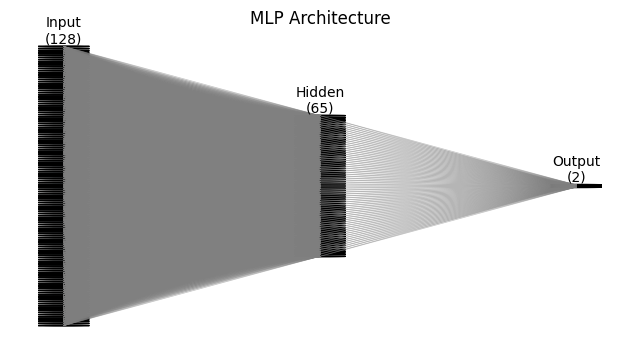

In [17]:
plot_mlp_architecture(clf_large)

## 🔄 PCA feature transformation

In [18]:
# Cell X: PCA dimensionality reduction
from sklearn.decomposition import PCA

# 1) Initialize PCA (fit only on training data)
pca = PCA(n_components=32, random_state=42)

# 2) Fit on X_train and transform both train & test
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

# 3) Check shapes to confirm reduction
print("X_train_pca shape:", X_train_pca.shape)  # (n_train_samples, 32)
print("X_test_pca  shape:", X_test_pca.shape)   # (n_test_samples, 32)

# (Optional) Examine how much variance is retained
explained = pca.explained_variance_ratio_.cumsum()
print("Total variance retained:", explained[-1])

X_train_pca shape: (68, 32)
X_test_pca  shape: (35, 32)
Total variance retained: 0.9265818393070243


In [19]:
# Cell Y: Re-standardize PCA outputs before model training
from sklearn.preprocessing import StandardScaler

# 1) Initialize a new scaler
scaler_pca = StandardScaler()

# 2) Fit on the PCA‐transformed training data, then apply to both
X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca)
X_test_pca_scaled  = scaler_pca.transform(X_test_pca)

# 3) Quick sanity check: zero mean/unit var on train
print("Post-PCA train means (first 3 comps):", 
      X_train_pca_scaled.mean(axis=0)[:3])
print("Post-PCA train stds  (first 3 comps):", 
      X_train_pca_scaled.std(axis=0)[:3])

Post-PCA train means (first 3 comps): [3.42862993e-17 6.20418749e-17 6.53072367e-18]
Post-PCA train stds  (first 3 comps): [1. 1. 1.]


## 🔁 Re-train and evaluate the model

In [20]:
clf_small = MLPClassifier(hidden_layer_sizes=(17,), max_iter=100, random_state=42)
clf_small.fit(X_train_pca_scaled, y_train)

/Users/kp/dev/python-sdk2/zkml-research/KYA_face/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(17,), max_iter=100, random_state=42)

In [21]:
print("Train accuracy:", clf_small.score(X_train_pca_scaled, y_train))
print("Test accuracy:", clf_small.score(X_test_pca_scaled,  y_test))

Train accuracy: 0.8970588235294118
Test accuracy: 0.8571428571428571


In [22]:
summarize_mlp(clf_small)

Layer sizes (including input and output): [32, 17, 2]
 ➔ Total layers (including input layer): 3
 ➔ Hidden layers: 1
 ➔ Output layer: 1
Total parameters: 597


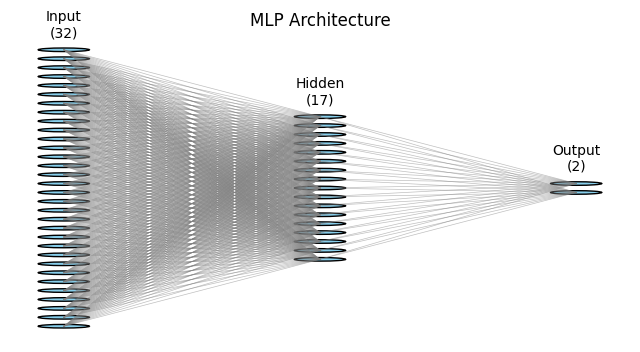

In [23]:
plot_mlp_architecture(clf_small)

## ⚙️ Transpile to Leo

In [24]:
# Get a random number for the program name generation between 0 and 10000
random_number = random.randint(0, 10000)

# Create a unique project name using the random number
leo_project_name = f"workshop_kya_face_{random_number}"

# Transpile the NN into Leo code
lt = LeoTranspiler(
    model=clf_small
)
lt.to_leo(
    path=cwd, project_name=leo_project_name, fixed_point_scaling_factor=16
)

In [25]:
# take a look at the transpiled code
leo_code_path = os.path.join(
    (os.path.join(cwd, leo_project_name, "src", "main.leo"))
)
with open(leo_code_path, "r") as f:
    leo_code = f.read()
print(leo_code)

// This file was automatically generated by the zkml LeoTranspiler.
program workshop_kya_face_2839.aleo {
    struct Struct0 {
  x0: i64,
  x1: i64
}
    transition main (struct0_0: Struct0, struct0_1: Struct0, struct0_2: Struct0, struct0_3: Struct0, struct0_4: Struct0, struct0_5: Struct0, struct0_6: Struct0, struct0_7: Struct0, struct0_8: Struct0, struct0_9: Struct0, struct0_10: Struct0, struct0_11: Struct0, struct0_12: Struct0, struct0_13: Struct0, struct0_14: Struct0, struct0_15: Struct0) -> (i64, i64) {
        let neuron_1_0: i64 = relu(-3i64 * struct0_0.x0 + 2i64 * struct0_0.x1 + 4i64 * struct0_1.x0 + 2i64 * struct0_1.x1 + -4i64 * struct0_2.x0 + -1i64 * struct0_2.x1 + -3i64 * struct0_3.x0 + -1i64 * struct0_3.x1 + -2i64 * struct0_4.x0 + 1i64 * struct0_4.x1 + 1i64 * struct0_5.x0 + 2i64 * struct0_5.x1 + 3i64 * struct0_6.x0 + 2i64 * struct0_6.x1 + 0i64 * struct0_7.x0 + 0i64 * struct0_7.x1 + 5i64 * struct0_8.x0 + 0i64 * struct0_8.x1 + 1i64 * struct0_9.x0 + -4i64 * struct0_9.x1 + 1i64 

## ▶️ Test execution of the Leo program

In [26]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [27]:
def show_image_and_predictions(test_index):
    test_features = X_test_pca_scaled[test_index:test_index+1]

    sample_meta = test_df.iloc[test_index]
    img_dir     = positive_dir_path if sample_meta['label'] == 1 else negative_dir_path
    image_path  = os.path.join(img_dir, sample_meta['filename'])

    # plot image
    img = Image.open(image_path)
    plt.figure(figsize=(3, 3))  
    plt.imshow(img)
    plt.axis('off')
    plt.title(sample_meta['filename'])
    plt.show()

    # sklearn’s probability
    python_probability_prediction = clf_small.predict_proba(test_features)
    print(f"Python probability prediction: {python_probability_prediction}")
    print(f"Predicted class: {np.argmax(python_probability_prediction)}\n")

    # Leo computation
    leo_computation = lt.run(input=test_features[0])

    print("Leo computation results")
    print(f"\tConstraints: {leo_computation.circuit_constraints}")
    print(f"\tRuntime: {leo_computation.runtime} seconds")
    print(f"\tInput: {leo_computation.input}")
    print(f"\tRaw output: {leo_computation.output}")
    print(f"\tDecimal output: {leo_computation.output_decimal}")

    # Convert list → array for sigmoid
    decimal_array = np.array(leo_computation.output_decimal, dtype=float)
    leo_probs = sigmoid(decimal_array)

    print(f"\tProbabilities after sigmoid: {leo_probs.tolist()}")
    print(f"\tPredicted class: {np.argmax(leo_probs)}")

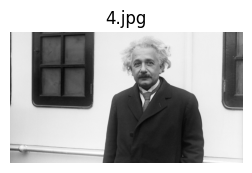

Python probability prediction: [[0.35216162 0.49049013]]
Predicted class: 1

Leo computation results
	Constraints: 269822
	Runtime: 1.8732600212097168 seconds
	Input: ['{ x0: 23i64, x1: 3i64 }', '{ x0: 15i64, x1: 19i64 }', '{ x0: -3i64, x1: -22i64 }', '{ x0: 4i64, x1: -1i64 }', '{ x0: 23i64, x1: -19i64 }', '{ x0: 13i64, x1: -23i64 }', '{ x0: 4i64, x1: -13i64 }', '{ x0: 2i64, x1: 2i64 }', '{ x0: 9i64, x1: -16i64 }', '{ x0: -2i64, x1: 14i64 }', '{ x0: 4i64, x1: 7i64 }', '{ x0: 12i64, x1: 0i64 }', '{ x0: -2i64, x1: 16i64 }', '{ x0: -6i64, x1: 0i64 }', '{ x0: -9i64, x1: -7i64 }', '{ x0: 17i64, x1: -4i64 }']
	Raw output: [-2539, -182]
	Decimal output: [-0.619873046875, -0.04443359375]
	Probabilities after sigmoid: [0.34981032548302954, 0.4888934288519495]
	Predicted class: 1


In [28]:
show_image_and_predictions(0)

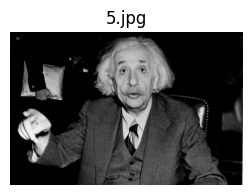

Python probability prediction: [[0.33428013 0.45543195]]
Predicted class: 1

Leo computation results
	Constraints: 269822
	Runtime: 1.787106990814209 seconds
	Input: ['{ x0: 21i64, x1: 3i64 }', '{ x0: 12i64, x1: 22i64 }', '{ x0: -3i64, x1: -14i64 }', '{ x0: 7i64, x1: 7i64 }', '{ x0: 25i64, x1: -14i64 }', '{ x0: 22i64, x1: -15i64 }', '{ x0: 4i64, x1: 0i64 }', '{ x0: 2i64, x1: 2i64 }', '{ x0: 16i64, x1: 5i64 }', '{ x0: 3i64, x1: -1i64 }', '{ x0: 0i64, x1: 9i64 }', '{ x0: -18i64, x1: 8i64 }', '{ x0: 14i64, x1: 25i64 }', '{ x0: -11i64, x1: 2i64 }', '{ x0: -35i64, x1: 3i64 }', '{ x0: -30i64, x1: 0i64 }']
	Raw output: [-3142, -981]
	Decimal output: [-0.76708984375, -0.239501953125]
	Probabilities after sigmoid: [0.31710896744930084, 0.4404090902036582]
	Predicted class: 1


In [29]:
show_image_and_predictions(1)

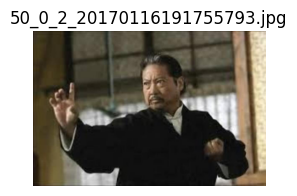

Python probability prediction: [[0.57518259 0.24481107]]
Predicted class: 0

Leo computation results
	Constraints: 269822
	Runtime: 1.772223949432373 seconds
	Input: ['{ x0: 2i64, x1: -3i64 }', '{ x0: 25i64, x1: 8i64 }', '{ x0: 14i64, x1: 18i64 }', '{ x0: 33i64, x1: 1i64 }', '{ x0: -3i64, x1: 10i64 }', '{ x0: 0i64, x1: 1i64 }', '{ x0: 3i64, x1: -7i64 }', '{ x0: 9i64, x1: -11i64 }', '{ x0: 17i64, x1: 20i64 }', '{ x0: -1i64, x1: 19i64 }', '{ x0: -24i64, x1: 5i64 }', '{ x0: 17i64, x1: 18i64 }', '{ x0: -6i64, x1: 4i64 }', '{ x0: 6i64, x1: -11i64 }', '{ x0: -13i64, x1: -11i64 }', '{ x0: 12i64, x1: -37i64 }']
	Raw output: [1128, -5076]
	Decimal output: [0.275390625, -1.2392578125]
	Probabilities after sigmoid: [0.5684158138804382, 0.22456520062887408]
	Predicted class: 0


In [30]:
show_image_and_predictions(13)

Note:
* the two probabilities need not sum to 1 because each class is modelled with an independent sigmoid, not a shared soft-max.
* small deviations in the probabilities between the Python and the Leo variant come from the fixed point number representation.

## 🚀 Deploy the Leo program

In [31]:
print(os.path.join(cwd, leo_project_name))

/Users/kp/dev/python-sdk2/zkml-research/KYA_face/workshop_kya_face_2839


Open the directory above, update the private key with a funded one in the `.env` file and run `leo deploy --broadcast`. Then, check for the transaction to land in the [Provable testnet explorer](https://testnet.explorer.provable.com/).

## 💡 Extension ideas
### Machine Learning
* Add data augmentation
* Add early stopping and validation approach in training
* Explore data quantization and other ML models
* ...

### Zero Knowledge
* ML model parameters as private inputs (so no one can steal your model)
* Hash model parameters to commit to an identity
* Store result on-chain
* ...

Check out the [Provable KYA app](https://kya.provable.com/) where most of these ideas are already implemented, and the training is done entirelly locally in your browser!

## 🗣️ Discussion
Wa are interested in a broad discussion with you, including the following aspects:
* Applications
* Security
* Technical improvements
* ...